# Study 779 — Devil-Price 😈

*For the curious.* 666 is the number of the beast — the most famous unlucky number there is — and the S&P 500's 2009 crash bottom near **666** is annotated to death as a 'devilish low' (it was actually the start of a decade-long bull). So does a **stock** whose price sits on a 666 handle ($6.66, $66.6, $666…) carry a curse and then lag? We sorted the S&P 100 every week and asked the tape.

## The claim, and why it's a clean test

A share price mantissa is visible in real time, so ranking names by how close their price is to the nearest 666 level and shorting the closest quintile is zero-look-ahead. The trick: the distance is **decade-invariant** — $6.66, $66.6 and $666 all score identically — so the 'devil' bucket is full every week. We measure **cross-sectionally demeaned** returns, so the market drops out and we're not just measuring beta.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from devil_price import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching S&P 100 + SPY once (needs network)")
    dt.fetch()
panel, spy = dt.load_real()
events = st.build_panel_events(panel, spy)
table = st.build_sort_table(events)
print(f"panel loaded; {len(events)} weekly rebalances over {panel.shape[1]} names")


panel loaded; 976 weekly rebalances over 98 names


## Where the devil sits on the price circle

Every price maps to a point on the log-price circle; the beast is at `log10(6.66) = 0.82`. Distance 0 = on a 666 handle, 0.5 = maximally far.

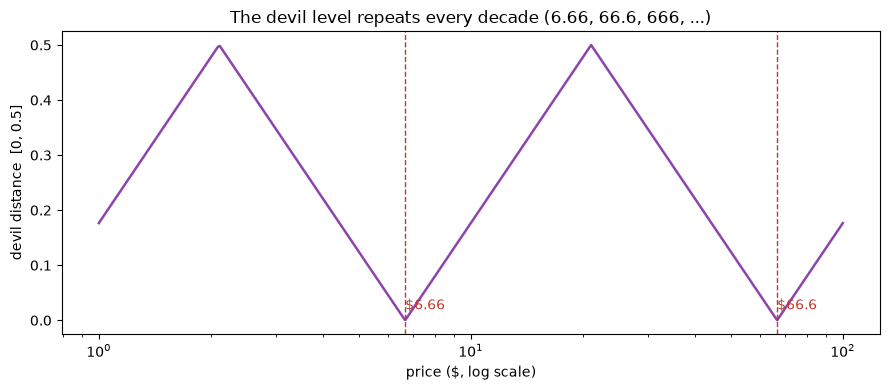

In [2]:
xs = np.linspace(1, 100, 4000)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xs, dt.devil_distance(xs), color='#8e44ad', lw=1.8)
for lv in (6.66, 66.6):
    ax.axvline(lv, color='#c0392b', ls='--', lw=1)
    ax.annotate(f'${lv}', (lv, 0.02), color='#c0392b')
ax.set_xscale('log'); ax.set_xlabel('price ($, log scale)')
ax.set_ylabel('devil distance  [0, 0.5]')
ax.set_title('The devil level repeats every decade (6.66, 66.6, 666, ...)')
plt.tight_layout(); plt.show()

## The picture: forward return by devil-distance decile

Bin 0 is *nearest* the beast; bin 9 is farthest. If the curse were real, the left bars would be deeply negative.

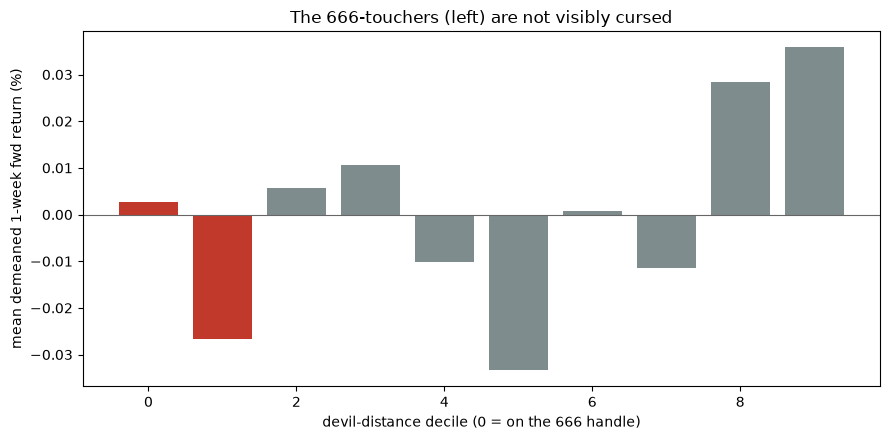

In [3]:
prof = st.distance_profile(events, horizon='s')
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#c0392b' if i < 2 else '#7f8c8d' for i in range(len(prof))]
ax.bar(prof.index, prof.values * 100, color=colors)
ax.axhline(0, color='0.4', lw=0.8)
ax.set_xlabel('devil-distance decile (0 = on the 666 handle)')
ax.set_ylabel('mean demeaned 1-week fwd return (%)')
ax.set_title('The 666-touchers (left) are not visibly cursed')
plt.tight_layout(); plt.show()

## The numbers

| cut | mean | *t* | hit rate |
|---|--:|--:|--:|
| devil quintile, 1-week (demeaned) | -0.006% | **-0.22** | — |
| clean − devil spread, 1-week | +0.036% | +0.82 | 530/976 |
| clean − devil spread, 1-month (~4x overlap) | +0.183% | **+2.28** | 532/976 |

The 666-touchers do **not** measurably underperform at the clean weekly horizon (*t* = -0.22 — a dead zero). The spread carries the folklore's sign (clean beats devil) and the *monthly* cut even shows *t* = +2.28… but that's an illusion — see the quants' notebook, where de-overlapping the windows drops it to *t* = +1.42.

In [4]:
for label, col in [('devil 1wk (dm)','devil_s_dm'),('LS 1wk','ls_s'),('LS 1mo','ls_l')]:
    s = st.one_sample_t(table[col].values)
    print(f'{label:<14s} n={s["n"]:4d}  mean={s["mean"]*100:+.4f}%  t={s["t"]:+.3f}')

devil 1wk (dm) n= 976  mean=-0.0061%  t=-0.216
LS 1wk         n= 976  mean=+0.0365%  t=+0.823
LS 1mo         n= 976  mean=+0.1827%  t=+2.281


## So what?

The number-of-the-beast price sort is a **faint, folklore-signed lean** (the clean names edge out the 666-touchers) that only *looks* significant through a window-overlap trick and evaporates under a clean non-overlapping test. And a stock's nominal price digit is economically meaningless (it's just split history), so there's no mechanism to hang it on. Verdict: **Weak signal, Mirage tradability.** The quants' notebook has the placebo, the jackknife, the de-overlapped re-run and the synthetic control.